R2: 0.7541736364364624
MAE: 29.443700790405273
RMSE: 38.011986699099275


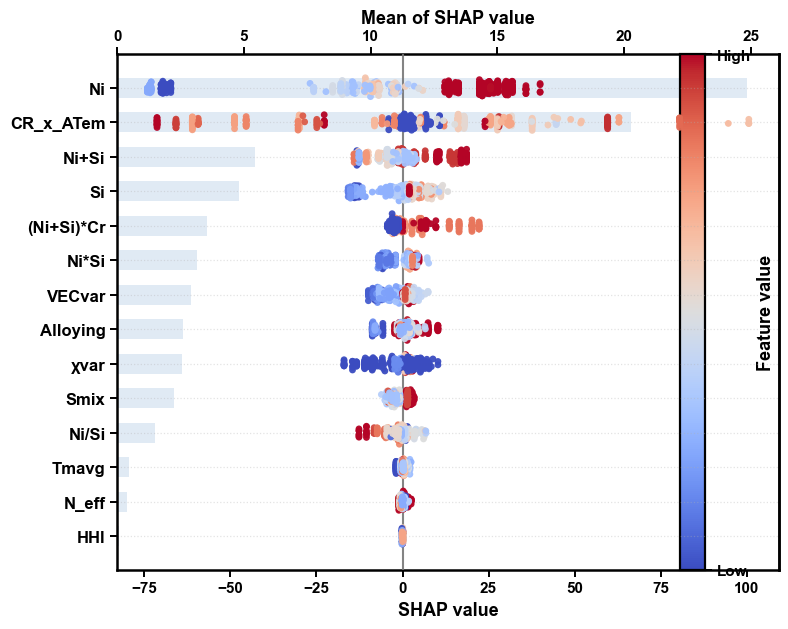

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# =========================
# 1. Read data
# =========================
FILE_PATH = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/Feature.xlsx"
SHEET_NAME = 0
TARGET_COL = "HV"

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df.columns = df.columns.astype(str).str.strip()

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET_COL])

id_like_cols = [
    c for c in df.columns
    if c.lower() in ["id", "sample id", "no.", "number", "index"]
]

DROP_COLS = [TARGET_COL] + id_like_cols

X = df.drop(columns=DROP_COLS, errors="ignore")
y = df[TARGET_COL]

X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

# =========================
# 2. Train XGBoost model
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# =========================
# 3. SHAP calculation
# =========================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# =========================
# 4. Select Top features
# =========================
TOP_N = 15
TOP_N = min(TOP_N, X.shape[1])

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[-TOP_N:][::-1]

top_features = X.columns[feature_order]
top_mean_abs = mean_abs_shap[feature_order]

shap_top = shap_values[:, feature_order]
X_top = X[top_features]

y_pos = np.arange(TOP_N)

# =========================
# 5. Plot style
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.linewidth"] = 1.6
plt.rcParams["xtick.major.width"] = 1.4
plt.rcParams["ytick.major.width"] = 1.4
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

fig, ax = plt.subplots(figsize=(8, 6.4))

# transparent background
fig.patch.set_alpha(0)
fig.patch.set_facecolor("none")

ax.set_zorder(10)
ax.patch.set_alpha(0)

# background bar axis
ax_bar = ax.twiny()
ax_bar.set_zorder(0)
ax_bar.patch.set_alpha(0)

bar_color = "#A9C4E2"

ax_bar.barh(
    y_pos,
    top_mean_abs,
    height=0.58,
    color=bar_color,
    alpha=0.35,
    edgecolor="none",
    linewidth=0,
    zorder=-10
)

ax_bar.set_xlabel(
    "Mean of SHAP value",
    fontsize=13,
    fontweight="bold"
)
ax_bar.tick_params(axis="x", labelsize=11, width=1.4, length=5)
ax_bar.set_xlim(0, top_mean_abs.max() * 1.05)

# SHAP scatter
cmap = plt.cm.coolwarm
rng = np.random.default_rng(42)

for i, feature in enumerate(top_features):
    shap_i = shap_top[:, i]
    value_i = X_top[feature].values

    norm = Normalize(
        vmin=np.nanpercentile(value_i, 1),
        vmax=np.nanpercentile(value_i, 99)
    )

    colors = cmap(norm(value_i))
    jitter = rng.normal(0, 0.08, size=len(shap_i))

    ax.scatter(
        shap_i,
        np.full_like(shap_i, i, dtype=float) + jitter,
        c=colors,
        s=24,
        alpha=0.95,
        linewidths=0,
        zorder=20
    )

ax.axvline(0, color="#777777", linewidth=1.5, alpha=0.9, zorder=15)

# y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(
    top_features,
    fontsize=12,
    fontweight="bold"
)
ax.invert_yaxis()

ax.set_xlabel(
    "SHAP value",
    fontsize=13,
    fontweight="bold"
)
ax.tick_params(axis="x", labelsize=11, width=1.4, length=5)
ax.tick_params(axis="y", labelsize=12, width=1.4, length=5)

# grid
ax.grid(axis="y", linestyle=":", linewidth=0.9, alpha=0.35)
ax.set_axisbelow(True)

# colorbar
sm = ScalarMappable(cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(
    "Feature value",
    fontsize=13,
    fontweight="bold"
)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Low", "High"])
cbar.ax.tick_params(labelsize=11, width=1.4, length=5)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")

# spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(True)
ax.spines["right"].set_linewidth(1.8)

ax_bar.spines["right"].set_visible(True)
ax_bar.spines["right"].set_linewidth(1.8)
ax_bar.spines["right"].set_color("black")

ax_bar.spines["left"].set_visible(False)
ax_bar.spines["bottom"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

for spine in ax_bar.spines.values():
    spine.set_linewidth(1.8)

plt.tight_layout()

plt.savefig(
    "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/XGBoost_SHAP_combined.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

R2: 0.5870853217686629
MAE: 0.0599796480463513
RMSE: 0.0772894121654037


/var/folders/jt/2gvzynk95l5bq44vwtsyyqrm0000gn/T/ipykernel_27506/3118458250.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


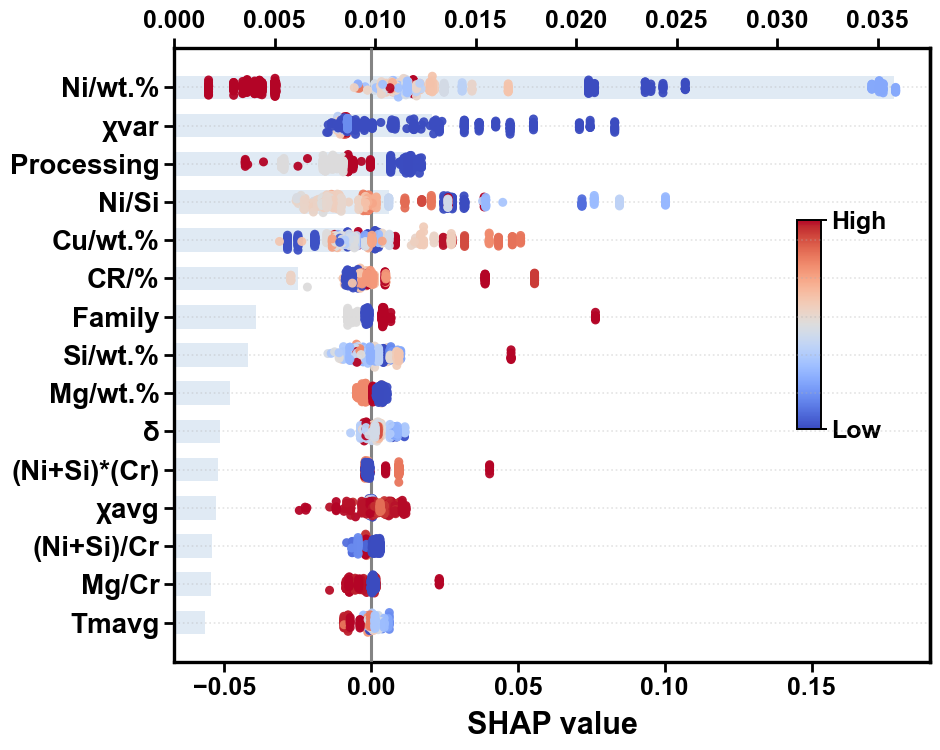

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# =========================
# 1. Read data
# =========================
FILE_PATH = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/Feature.xlsx"
SHEET_NAME = 2
TARGET_COL = "Q3-Euclidean"
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df.columns = df.columns.astype(str).str.strip()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET_COL])
id_like_cols = [
    c for c in df.columns
    if c.lower() in ["id", "sample id", "no.", "number", "index"]
]
DROP_COLS = [TARGET_COL] + id_like_cols
X = df.drop(columns=DROP_COLS, errors="ignore")
y = df[TARGET_COL]
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())
# =========================
# 2. Train XGBoost model
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = XGBRegressor(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
# =========================
# 3. SHAP calculation
# =========================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
# =========================
# 4. Select Top features
# =========================
TOP_N = 15
TOP_N = min(TOP_N, X.shape[1])
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[-TOP_N:][::-1]
top_features = X.columns[feature_order]
top_mean_abs = mean_abs_shap[feature_order]
shap_top = shap_values[:, feature_order]
X_top = X[top_features]
y_pos = np.arange(TOP_N)
# =========================
# 5. Plot style
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.linewidth"] = 2.2
plt.rcParams["xtick.major.width"] = 2.0
plt.rcParams["ytick.major.width"] = 2.0
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"
fig, ax = plt.subplots(figsize=(9.5, 7.6))
fig.patch.set_alpha(0)
fig.patch.set_facecolor("none")
ax.set_zorder(10)
ax.patch.set_alpha(0)
ax_bar = ax.twiny()
ax_bar.set_zorder(0)
ax_bar.patch.set_alpha(0)
bar_color = "#A9C4E2"
ax_bar.barh(
    y_pos,
    top_mean_abs,
    height=0.62,
    color=bar_color,
    alpha=0.35,
    edgecolor="none",
    linewidth=0,
    zorder=-10
)
# ax_bar.set_xlabel(
#     "Mean of SHAP value",
#     fontsize=22,
#     fontweight="bold",
#     labelpad=8
# )
ax_bar.tick_params(axis="x", labelsize=18, width=2.0, length=7)
ax_bar.set_xlim(0, top_mean_abs.max() * 1.05)
cmap = plt.cm.coolwarm
rng = np.random.default_rng(42)
for i, feature in enumerate(top_features):
    shap_i = shap_top[:, i]
    value_i = X_top[feature].values
    norm = Normalize(
        vmin=np.nanpercentile(value_i, 1),
        vmax=np.nanpercentile(value_i, 99)
    )
    colors = cmap(norm(value_i))
    jitter = rng.normal(0, 0.08, size=len(shap_i))
    ax.scatter(
        shap_i,
        np.full_like(shap_i, i, dtype=float) + jitter,
        c=colors,
        s=42,
        alpha=0.95,
        linewidths=0,
        zorder=20
    )
ax.axvline(0, color="#777777", linewidth=2.2, alpha=0.9, zorder=15)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    top_features,
    fontsize=20,
    fontweight="bold"
)
ax.invert_yaxis()
ax.set_xlabel(
    "SHAP value",
    fontsize=22,
    fontweight="bold",
    labelpad=8
)
ax.tick_params(axis="x", labelsize=18, width=2.0, length=7)
ax.tick_params(axis="y", labelsize=20, width=2.0, length=7)
ax.grid(axis="y", linestyle=":", linewidth=1.2, alpha=0.35)
ax.set_axisbelow(True)

# =========================
# Inset colorbar inside the plot
# =========================
sm = ScalarMappable(cmap=cmap)
sm.set_array([])

cax = inset_axes(
    ax,
    width="3.2%",
    height="34%",
    loc="center",
    bbox_to_anchor=(0.34, 0.05, 1, 1),  # 控制位置：x越大越靠右，y越大越靠上
    bbox_transform=ax.transAxes,
    borderpad=0
)

cbar = plt.colorbar(sm, cax=cax)
# cbar.set_label(
#     "Feature value",
#     fontsize=15,
#     fontweight="bold",
#     labelpad=8
# )
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Low", "High"])
cbar.ax.tick_params(labelsize=18, width=1.4, length=4)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")

cbar.outline.set_linewidth(1.4)

# =========================
# Spines
# =========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(True)
ax.spines["right"].set_linewidth(2.4)
ax_bar.spines["right"].set_visible(True)
ax_bar.spines["right"].set_linewidth(2.4)
ax_bar.spines["right"].set_color("black")
ax_bar.spines["left"].set_visible(False)
ax_bar.spines["bottom"].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(2.4)
for spine in ax_bar.spines.values():
    spine.set_linewidth(2.4)
plt.tight_layout()
plt.savefig(
    "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/XGBoost_SHAP_combined_largefont.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)
plt.show()